In [12]:
import pickle
from fileinput import close
import pandas as pd



with open("results.pkl", "rb") as f:
    results = pickle.load(f)

results.keys()





/home/isc-den/software/mniconda3/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


dict_keys(['model', 'model_quantile', 'forecast_q_median', 'forecast_q_median_price', 'metrics_q_median', 'target_scaler', 'cov_scaler', 'y_train_val', 'y_test', 'forecast', 'forecast_price', 'actual_price', 'rmse', 'smape', 'backtest', 'historical_forecasts', 'historical_forecasts_quantile', 'historical_actual_log_ret', 'historical_actual_log_ret_quantile', 'historical_forecast_price', 'historical_forecast_price_quantile', 'historical_actual_price', 'trading', 'trading_quantile', 'feature_importances', 'df_raw', 'df_feat', 'cov_train_val', 'cov_test_sc', 'y_train_val_sc', 'cov_train_val_sc'])

In [13]:
feature_importances = results["y_train_val_sc"]


feature_importances.columns

Index(['log_return_morgen'], dtype='object')

dict_keys(['equity_curve', 'strategy_returns', 'total_return', 'sharpe_like', 'max_drawdown'])

/tmp/ipykernel_352878/3646318652.py:11: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/isc-den/software/mniconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


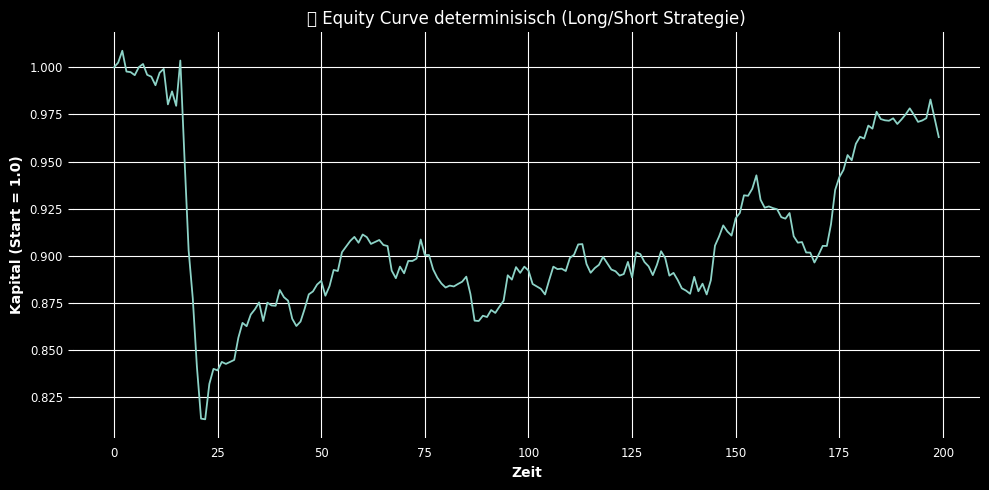

In [14]:
df = results['trading']
df.keys()
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df["equity_curve"])
plt.title("📈 Equity Curve determinisisch (Long/Short Strategie)")
plt.xlabel("Zeit")
plt.ylabel("Kapital (Start = 1.0)")
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipykernel_352878/757416422.py:11: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/isc-den/software/mniconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


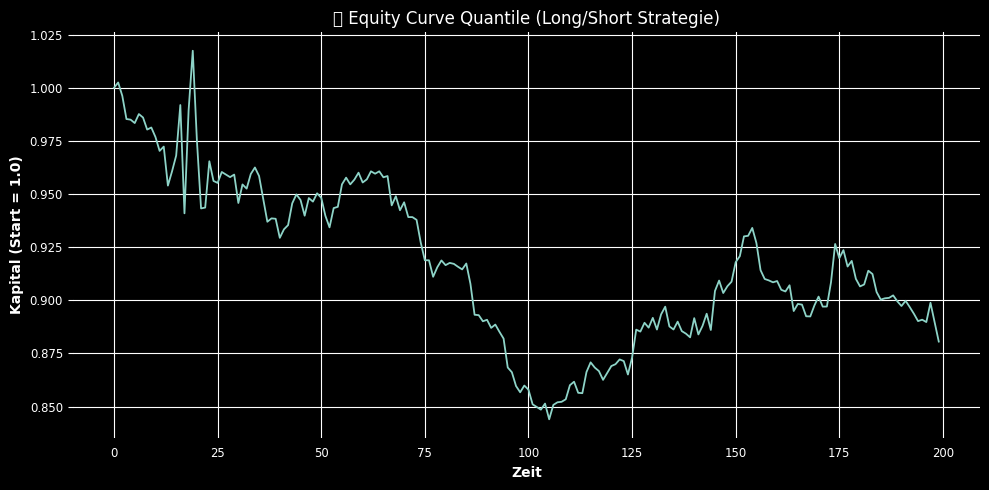

In [15]:
df = results['trading_quantile']
df.keys()
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df["equity_curve"])
plt.title("📈 Equity Curve Quantile (Long/Short Strategie)")
plt.xlabel("Zeit")
plt.ylabel("Kapital (Start = 1.0)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
historical_forecasts = results["historical_actual_log_ret_quantile"]
# Korrektur: Wir extrahieren die Werte als NumPy Array mit .values()
forecast_values = historical_forecasts["log_return_morgen"].values()

# Das Resultat ist ein 2D-Array (Zeit x Komponenten/Features).
# Da Sie nur eine Komponente (log_return_morgen) haben, wählen Sie die erste Spalte (Index 0).
# Wir verwenden .flatten() oder wählen die Spalte [:, 0].
forecast_1d_array = forecast_values.flatten()

# Nun die deskriptiven Statistiken berechnen:
print(pd.Series(forecast_1d_array).sum())

0.17970112328355986


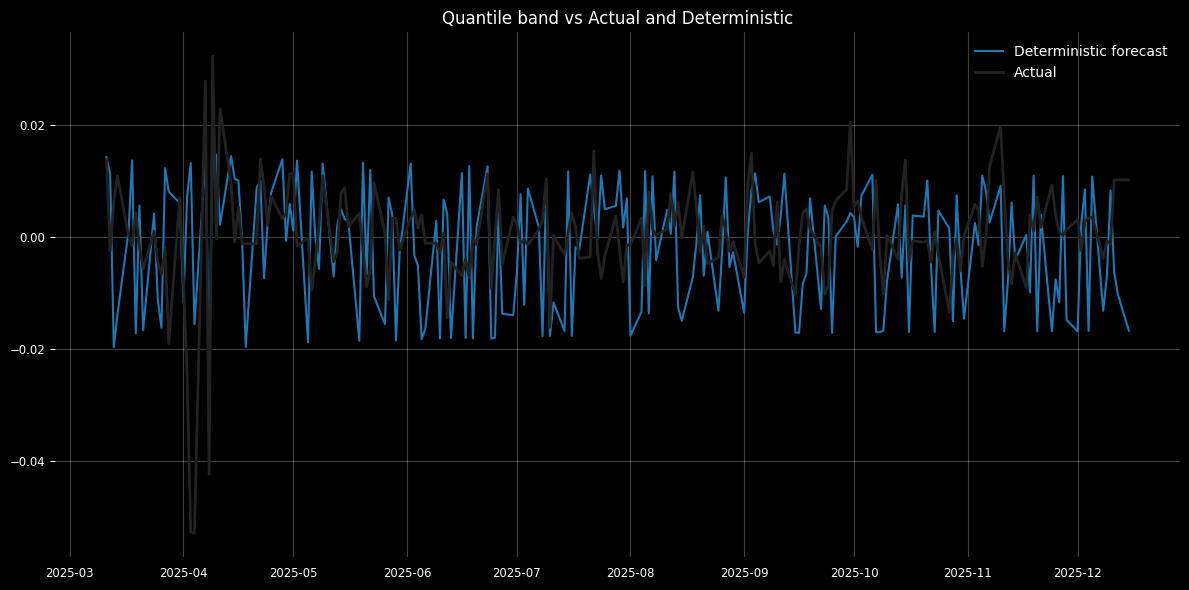

<Axes: title={'center': 'Quantile band vs Actual and Deterministic'}>

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def to_pd_series(x):
    if x is None:
        return None
    if hasattr(x, "pd_series"):
        try:
            return x.pd_series()
        except Exception:
            pass
    if hasattr(x, "to_series"):
        try:
            return x.to_series()
        except Exception:
            pass
    if hasattr(x, "to_dataframe"):
        try:
            df = x.to_dataframe()
            if isinstance(df, pd.DataFrame) and df.shape[1] >= 1:
                return df.iloc[:, 0]
        except Exception:
            pass
    if isinstance(x, pd.DataFrame):
        return x.iloc[:, 0]
    if isinstance(x, pd.Series):
        return x
    # fallback for numpy/iterable
    try:
        return pd.Series(np.asarray(x))
    except Exception:
        return None

def plot_quantile_band(
        actual,
        det_forecast=None,
        q01=None,
        q05=None,
        q09=None,
        title="Actual vs Deterministic vs Quantile (0.1/0.5/0.9)",
        figsize=(12, 6),
        colors=None,
):
    colors = colors or {
        "actual": "#222222",
        "det": "#1f77b4",
        "q05": "#ff7f0e",
        "band": "#ff7f0e",
    }

    s_actual = to_pd_series(actual)
    s_det = to_pd_series(det_forecast)
    s_q01 = to_pd_series(q01)
    s_q05 = to_pd_series(q05)
    s_q09 = to_pd_series(q09)

    parts = {}
    if s_actual is not None:
        parts["actual"] = s_actual
    if s_det is not None:
        parts["det"] = s_det
    if s_q01 is not None:
        parts["q01"] = s_q01
    if s_q05 is not None:
        parts["q05"] = s_q05
    if s_q09 is not None:
        parts["q09"] = s_q09

    if not parts:
        raise ValueError("Provide at least one series (actual, det_forecast or quantiles)")

    df = pd.concat(parts.values(), axis=1, keys=parts.keys()).sort_index()

    fig, ax = plt.subplots(figsize=figsize)

    if "q01" in df.columns and "q09" in df.columns:
        lower = df["q01"]
        upper = df["q09"]
        valid = ~(lower.isna() | upper.isna())
        ax.fill_between(
            df.index,
            lower,
            upper,
            where=valid,
            color=colors["band"],
            alpha=0.18,
            label="Quantile 0.1-0.9",
        )

    if "q05" in df.columns:
        ax.plot(df.index, df["q05"], color=colors["q05"], linestyle="--", label="Quantile 0.5 (median)")

    if "det" in df.columns:
        ax.plot(df.index, df["det"], color=colors["det"], label="Deterministic forecast", linewidth=1.5)

    if "actual" in df.columns:
        ax.plot(df.index, df["actual"], color=colors["actual"], label="Actual", linewidth=2)

    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
    return ax

# --- Example usage: adjust keys to match your `results` structure if needed ---
# Uses variables commonly present in this notebook:
plot_quantile_band(
    actual=results.get("y_test", results.get("y_test_series")),
    det_forecast=results.get("forecast"),
    q01=results.get("forecast_price_bt_quantile_01"),
    q05=results.get("forecast_price_bt_quantile_05"),
    q09=results.get("forecast_price_bt_quantile_09"),
    title="Quantile band vs Actual and Deterministic"
)

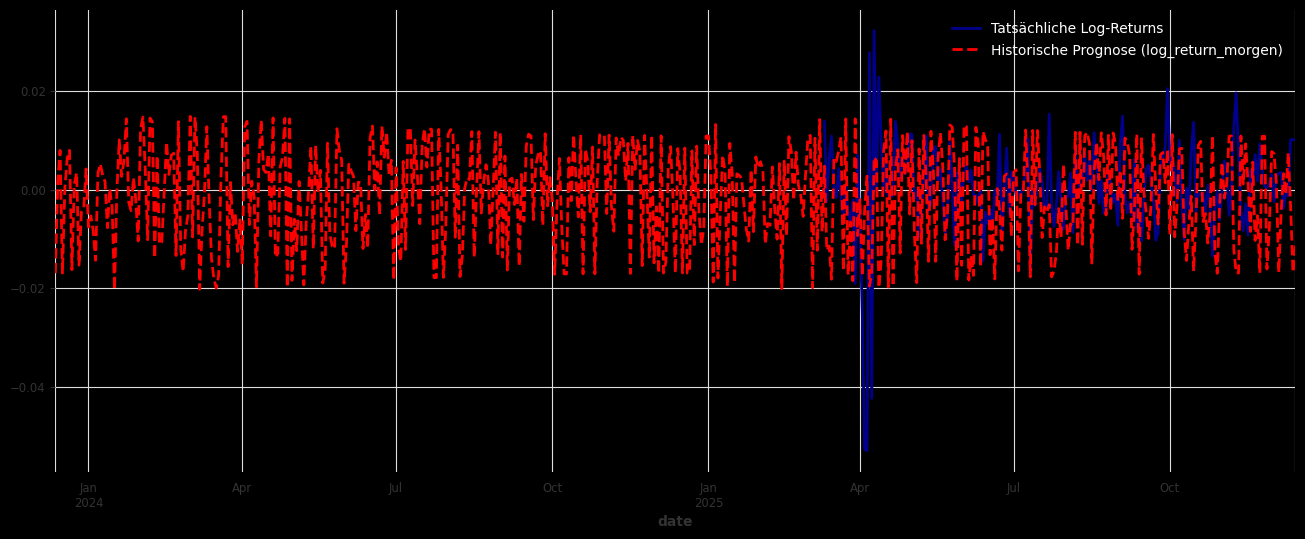

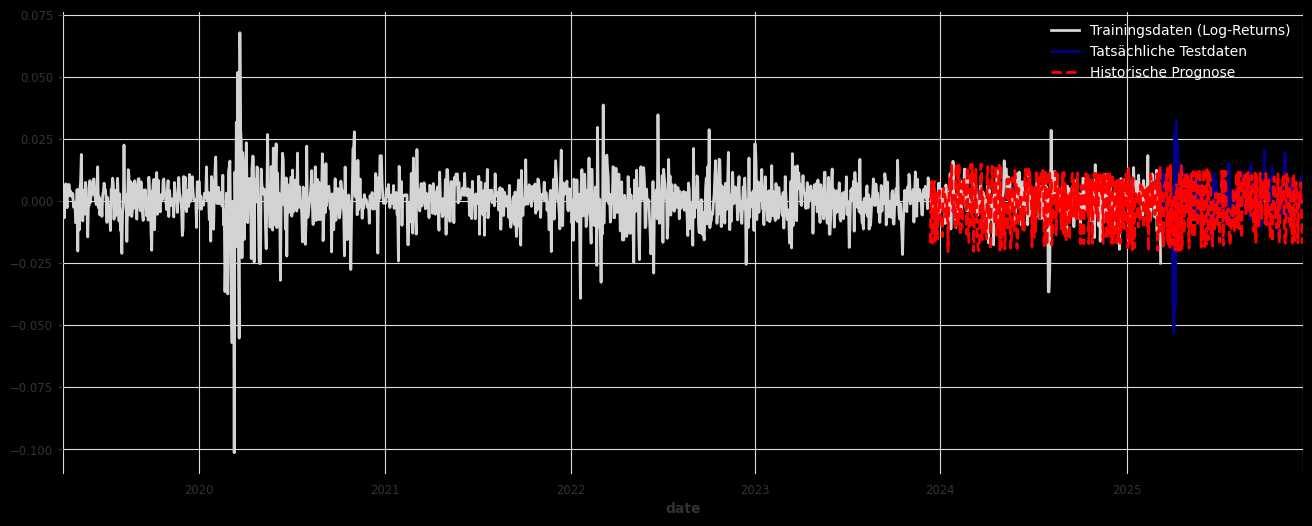

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
# Die TimeSeries-Objekte von Darts haben eine eingebaute Plot-Methode

# ----------------------------------------------------------------------
# 1. Sicherstellen, dass die Prognose als TimeSeries vorliegt
# ----------------------------------------------------------------------
# Abhängig davon, wie results gespeichert sind, müssen wir die TimeSeries extrahieren.
# Wir nehmen an, dass 'forecast_series' das Darts TimeSeries-Objekt der Prognose ist.
forecast_series = results["historical_forecasts"]["log_return_morgen"]
y_test = results["y_test"]
y_train_val = results["y_train_val"]
# ----------------------------------------------------------------------
# 2. Die Visualisierung der Prognose (Testbereich)
# ----------------------------------------------------------------------
plt.figure(figsize=(16, 6))
plt.title("Historische Prognosen vs. Tatsächliche Log-Returns (Test-Set)")

# Tatsächliche Werte (oft in Schwarz oder Dunkelgrau)
y_test.plot(label="Tatsächliche Log-Returns", color="darkblue")

# Prognostizierte Werte (oft in Rot oder Orange)
# Wir plotten die Vorhersage direkt gegen die tatsächlichen Testdaten.
forecast_series.plot(label="Historische Prognose (log_return_morgen)", color="red", linestyle="--")

plt.legend()
plt.grid(True)
plt.show()

# ----------------------------------------------------------------------
# 3. Optional: Gesamter Verlauf (Train + Test + Prognose)
# ----------------------------------------------------------------------

# Hinzufügen des Training-Sets, um den Gesamtkontext zu sehen
plt.figure(figsize=(16, 6))
plt.title("Gesamter Zeitverlauf: Training, Test und Prognose")

# Training-Set (grau)
y_train_val.plot(label="Trainingsdaten (Log-Returns)", color="lightgrey")

# Tatsächliche Werte im Test-Set (dunkelblau)
y_test.plot(label="Tatsächliche Testdaten", color="darkblue")

# Prognose (rot)
forecast_series.plot(label="Historische Prognose", color="red", linestyle="--")

plt.legend()
plt.grid(True)
plt.show()

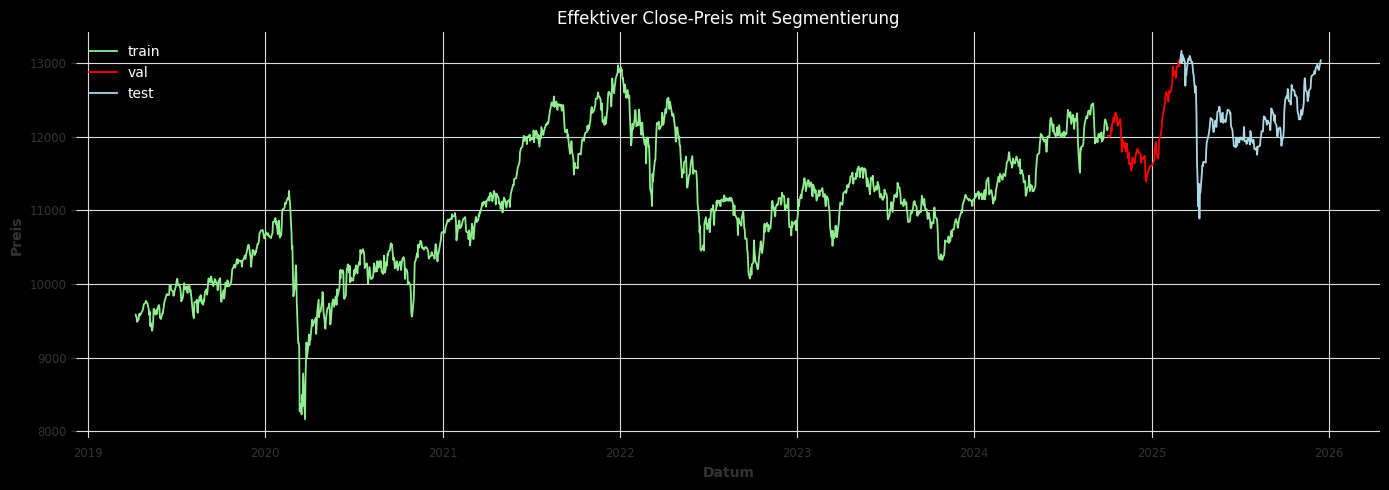

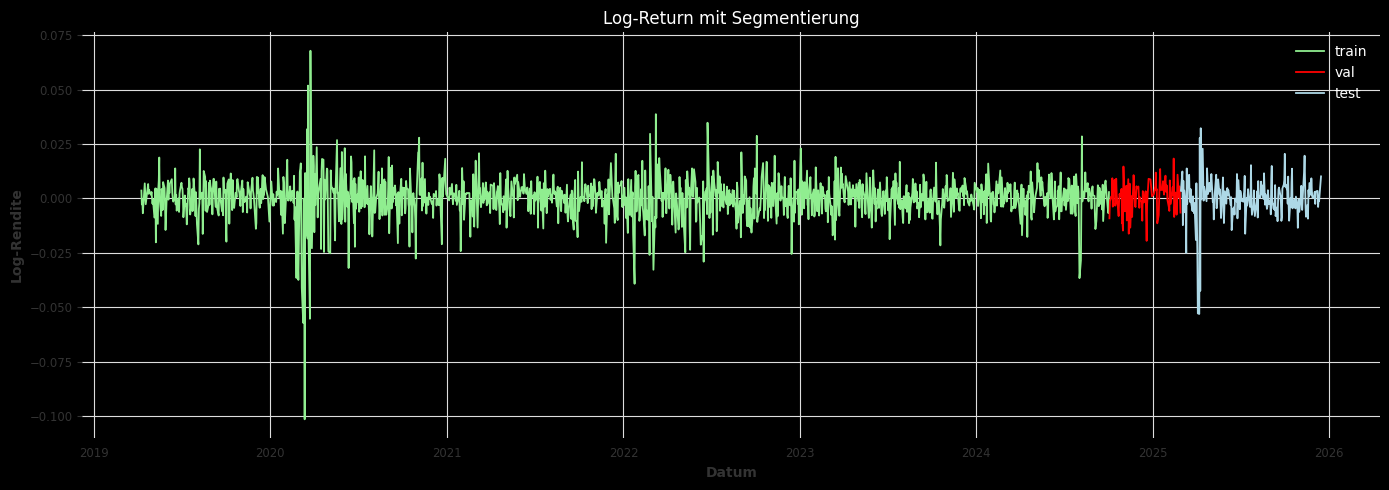

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Original-DataFrame
df = results["df_feat"].copy()


# Zeit-Parameter
test_size = results["data"].test_size if "data" in results else 200
val_size = results["data"].val_size if "data" in results else 100
total_len = len(df)

# Zeitsegmente berechnen
train_end = total_len - test_size - val_size
val_end = total_len - test_size

df["split"] = "train"
df.iloc[train_end:val_end, df.columns.get_loc("split")] = "val"
df.iloc[val_end:, df.columns.get_loc("split")] = "test"

colors = {"train": "lightgreen", "val": "red", "test": "lightblue"}

# === Plot 1: Close Preis mit Segmentfarben ===
plt.figure(figsize=(14, 5))
for split, color in colors.items():
    segment = df[df["split"] == split]
    plt.plot(segment.index, segment["close"], label=split, color=color)
plt.title("Effektiver Close-Preis mit Segmentierung")
plt.xlabel("Datum")
plt.ylabel("Preis")
plt.legend()
plt.tight_layout()
plt.show()

# === Plot 2: Log-Returns mit Segmentfarben ===
plt.figure(figsize=(14, 5))
for split, color in colors.items():
    segment = df[df["split"] == split]
    plt.plot(segment.index, segment["log_return"], label=split, color=color)
plt.title("Log-Return mit Segmentierung")
plt.xlabel("Datum")
plt.ylabel("Log-Rendite")
plt.legend()
plt.tight_layout()
plt.show()


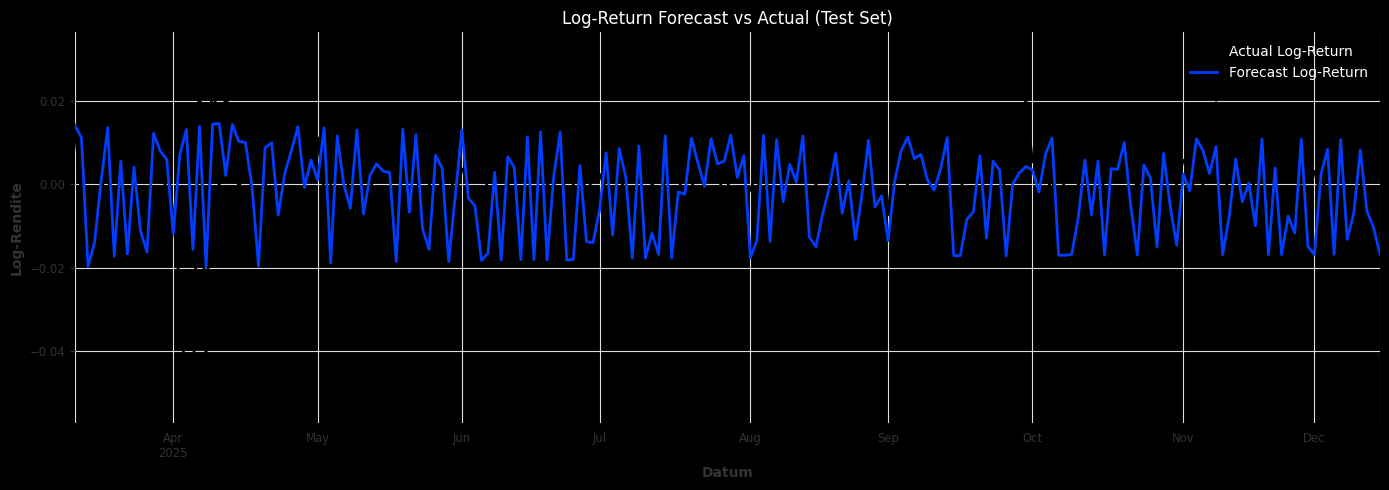

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
results["y_test"].plot(label="Actual Log-Return")
results["forecast"].plot(label="Forecast Log-Return")
plt.title("Log-Return Forecast vs Actual (Test Set)")
plt.xlabel("Datum")
plt.ylabel("Log-Rendite")
plt.legend()
plt.tight_layout()
plt.show()




In [10]:
feature_importances = results["feature_importances"]
feature_importances.keys()


dict_keys(['encoder_importance', 'decoder_importance', 'static_covariates_importance'])

<Figure size 800x600 with 0 Axes>

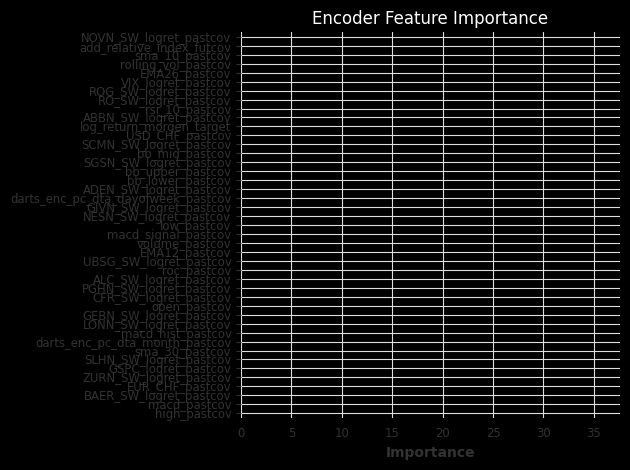

<Figure size 600x400 with 0 Axes>

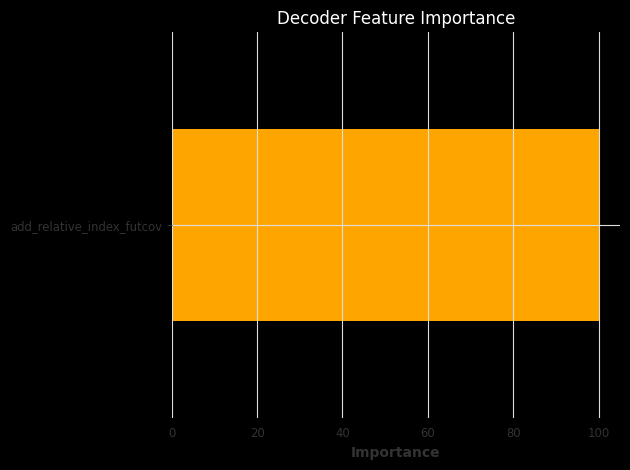

No static covariate importances to plot.


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

fi = results["feature_importances"]

# --- Encoder ---
encoder_df = fi["encoder_importance"].T
encoder_df.columns = ["importance"]
encoder_df = encoder_df.sort_values("importance", ascending=True)

plt.figure(figsize=(8,6))
encoder_df.plot(kind="barh", legend=False)
plt.title("Encoder Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# --- Decoder ---
decoder_df = fi["decoder_importance"].T
decoder_df.columns = ["importance"]
decoder_df = decoder_df.sort_values("importance", ascending=True)

plt.figure(figsize=(6,4))
decoder_df.plot(kind="barh", legend=False, color="orange")
plt.title("Decoder Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# --- Static Covariates ---
static_df = fi["static_covariates_importance"]

if static_df is not None and not static_df.empty:
    static_df = static_df.T
    static_df.columns = ["importance"]
    static_df = static_df.sort_values("importance", ascending=True)

    plt.figure(figsize=(6,4))
    static_df.plot(kind="barh", legend=False, color="green")
    plt.title("Static Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("No static covariate importances to plot.")

